<h2>Regression Models with Keras</h2>

<h3>Objective for this Notebook<h3>    
<h5> 1. How to use the Keras library to build a regression model.</h5>
<h5> 2. Download and Clean dataset </h5>
<h5> 3. Build a Neural Network </h5>
<h5> 4. Train and Test the Network. </h5>    

In [2]:
%pip install numpy
%pip install pandas
%pip install keras
%pip install requests
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

import warnings
warnings.simplefilter("ignore", FutureWarning)

In [5]:
path= 'https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0101EN/labs/data/concrete_data.csv'
filename="kerasRegressionData.csv"

In [6]:
import requests


def download(url, filename):
    response = requests.get(url)
    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write( response.content)
            print("File downloaded successfully!")
    else:
        print(f"Failed to download file. Status code: {response.status_code}")

download(path,filename=filename)

File downloaded successfully!


In [3]:
df = pd.read_csv("kerasRegressionData.csv")

In [6]:
df.shape

(1030, 9)

In [7]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [ ]:
# Checking for missing values
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [4]:
# Splitting data into predictors and targets
cols = df.columns
cols

Index(['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer',
       'Coarse Aggregate', 'Fine Aggregate', 'Age', 'Strength'],
      dtype='object')

#### Split data into predictors and target

In [5]:
cols = df.columns
predictors = df[cols[cols!="Strength"]] #All columns except "Strength"
target = df["Strength"]


In [8]:
predictors.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360


In [17]:
target.head()

0    79.99
1    61.89
2    40.27
3    41.05
4    44.30
Name: Strength, dtype: float64

### Normalize the data by substracting the mean and dividing by the standard deviation.

In [6]:
predictors_norm = (predictors - predictors.mean())/predictors.std()
predictors_norm.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
0,2.476712,-0.856472,-0.846733,-0.916319,-0.620147,0.862735,-1.217079,-0.279597
1,2.476712,-0.856472,-0.846733,-0.916319,-0.620147,1.055651,-1.217079,-0.279597
2,0.491187,0.795140,-0.846733,2.174405,-1.038638,-0.526262,-2.239829,3.551340
3,0.491187,0.795140,-0.846733,2.174405,-1.038638,-0.526262,-2.239829,5.055221
4,-0.790075,0.678079,-0.846733,0.488555,-1.038638,0.070492,0.647569,4.976069


In [7]:
n_cols = predictors_norm.shape[1]
n_cols

8

### Importing Keras Library

In [8]:
import keras
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

### Building a Network

In [45]:
def regression_model():
    # Creating the model
    model = Sequential()
    model.add(Dense(100, activation='relu', input_shape=(n_cols,)))
    model.add(Dense(80, activation='relu'))
    model.add(Dense(1))

    # Compiling model
    model.compile(optimizer=Adam(), loss="mean_squared_error", metrics=['mae'])
    return model

## Train and Test the Network


In [39]:
X_train, X_test, Y_train, Y_test = train_test_split(predictors_norm, target, test_size=0.12, random_state=42)

In [40]:
X_train.head()


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
929,-1.398650,0.360505,2.169034,0.675872,-0.034259,-0.101846,-1.628673,-0.279597
292,-0.948917,-0.332592,1.059607,-0.532320,0.334013,1.112240,0.088799,0.163652
752,2.476712,-0.856472,-0.846733,-0.401199,-1.038638,1.955927,-2.002850,-0.501222
100,1.376300,0.375573,-0.846733,-1.314367,1.723404,-1.553862,1.415879,-0.612034
1020,0.069203,0.545950,-0.846733,-0.195150,0.133137,-0.836214,0.697460,-0.279597


In [15]:
Y_train.head()

929     21.91
292     43.50
752     59.76
100     49.20
1020    42.14
Name: Strength, dtype: float64

In [72]:
# building the model
model = regression_model()

# fitting the model
history = model.fit(X_train, Y_train, epochs=150, verbose=2, validation_data=(X_test,Y_test))

Epoch 1/150


/Users/nombauser/Desktop/GIT/MyGitRepos/Coursera-Program/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 - 0s - 16ms/step - loss: 1461.4229 - mae: 34.3560 - val_loss: 1281.3518 - val_mae: 31.9299
Epoch 2/150
29/29 - 0s - 1ms/step - loss: 1135.3525 - mae: 29.4407 - val_loss: 842.2484 - val_mae: 24.9147
Epoch 3/150
29/29 - 0s - 1ms/step - loss: 618.8218 - mae: 20.1729 - val_loss: 344.3296 - val_mae: 15.1443
Epoch 4/150
29/29 - 0s - 1ms/step - loss: 255.8855 - mae: 12.7236 - val_loss: 208.1687 - val_mae: 11.9844
Epoch 5/150
29/29 - 0s - 1ms/step - loss: 204.1766 - mae: 11.4690 - val_loss: 189.6777 - val_mae: 11.4494
Epoch 6/150
29/29 - 0s - 1ms/step - loss: 188.2677 - mae: 11.1113 - val_loss: 178.2757 - val_mae: 11.2045
Epoch 7/150
29/29 - 0s - 1ms/step - loss: 176.7209 - mae: 10.8417 - val_loss: 170.4411 - val_mae: 10.9322
Epoch 8/150
29/29 - 0s - 1ms/step - loss: 168.1156 - mae: 10.5768 - val_loss: 161.3782 - val_mae: 10.6317
Epoch 9/150
29/29 - 0s - 1ms/step - loss: 161.2380 - mae: 10.3355 - val_loss: 155.6611 - val_mae: 10.4456
Epoch 10/150
29/29 - 0s - 1ms/step - loss: 156.7388 - 

### Evaluating the Model

In [73]:
test_loss, test_mae = model.evaluate(X_test, Y_test)
print(f"Test Loss: {round(test_loss,3)}, Test MAE: {round(test_mae,3)}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 984us/step - loss: 32.1880 - mae: 4.3891
Test Loss: 29.016, Test MAE: 4.113


#### Making Predictions

In [74]:
predictions = model.predict(X_test)
print(predictions[:8])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[[50.356743]
 [43.90881 ]
 [69.40853 ]
 [39.101887]
 [13.719501]
 [47.77387 ]
 [28.546022]
 [54.384743]]


In [75]:
print(Y_test[:8])

31      52.91
109     55.90
136     74.50
88      35.30
918     10.54
1025    44.28
870     23.69
318     45.37
Name: Strength, dtype: float64


#### Plotting Training History

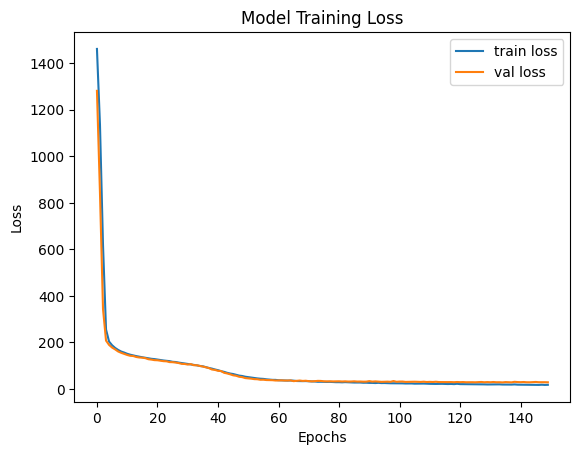

In [76]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label="train loss")
plt.plot(history.history['val_loss'], label='val loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Training Loss')
plt.show()